# Task
Build and evaluate a machine learning model to predict employee promotion based on the data in "train_LZdllcl.csv" and "test_2umaH9m.csv", using F1-score as the evaluation metric and generating a submission file.

## Load Data

### Subtask:
Load the training data from 'train_LZdllcl.csv' and the test data from 'test_2umaH9m.csv' into separate pandas DataFrames. Display the first few rows and basic information about both datasets.


**Reasoning**:
To load the datasets and display their initial rows and information, I need to import pandas, read both CSV files into separate DataFrames, and then use the `head()` and `info()` methods for each DataFrame as instructed.



In [ ]:
import pandas as pd

# Load the training data
train_df = pd.read_csv('/content/train_LZdllcl.csv')

# Load the test data
test_df = pd.read_csv('/content/test_2umaH9m.csv')

print("### Training DataFrame (train_df) - First 5 rows:\n")
print(train_df.head())
print("\n### Training DataFrame (train_df) - Info:\n")
train_df.info()

print("\n\n### Test DataFrame (test_df) - First 5 rows:\n")
print(test_df.head())
print("\n### Test DataFrame (test_df) - Info:\n")
test_df.info()

### Training DataFrame (train_df) - First 5 rows:

   employee_id         department     region         education gender  \
0        65438  Sales & Marketing   region_7  Master's & above      f   
1        65141         Operations  region_22        Bachelor's      m   
2         7513  Sales & Marketing  region_19        Bachelor's      m   
3         2542  Sales & Marketing  region_23        Bachelor's      m   
4        48945         Technology  region_26        Bachelor's      m   

  recruitment_channel  no_of_trainings  age  previous_year_rating  \
0            sourcing                1   35                   5.0   
1               other                1   30                   5.0   
2            sourcing                1   34                   3.0   
3               other                2   39                   1.0   
4               other                1   45                   3.0   

   length_of_service  KPIs_met >80%  awards_won?  avg_training_score  \
0                  8   

## Exploratory Data Analysis (EDA) - Training Data

### Subtask:
Perform exploratory data analysis on the training dataset. This includes checking data types, identifying missing values, examining descriptive statistics, and visualizing the distribution of the target variable and other relevant features. Analyze feature distributions and relationships with the target variable to gain insights.


**Reasoning**:
The first step in EDA is to identify and display the number of missing values for each column in the `train_df` to understand the extent of data incompleteness.



In [ ]:
print("### Missing values in train_df:\n")
print(train_df.isnull().sum())

### Missing values in train_df:

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64


**Reasoning**:
To understand the central tendency, dispersion, and unique values of both numerical and categorical features, I will generate descriptive statistics for all columns in the `train_df`.



In [ ]:
print("### Descriptive statistics for train_df (all columns):\n")
print(train_df.describe(include='all'))

### Descriptive statistics for train_df (all columns):

         employee_id         department    region   education gender  \
count   54808.000000              54808     54808       52399  54808   
unique           NaN                  9        34           3      2   
top              NaN  Sales & Marketing  region_2  Bachelor's      m   
freq             NaN              16840     12343       36669  38496   
mean    39195.830627                NaN       NaN         NaN    NaN   
std     22586.581449                NaN       NaN         NaN    NaN   
min         1.000000                NaN       NaN         NaN    NaN   
25%     19669.750000                NaN       NaN         NaN    NaN   
50%     39225.500000                NaN       NaN         NaN    NaN   
75%     58730.500000                NaN       NaN         NaN    NaN   
max     78298.000000                NaN       NaN         NaN    NaN   

       recruitment_channel  no_of_trainings           age  \
count             

**Reasoning**:
To visualize the distribution of the target variable 'is_promoted' and check for class imbalance, I will use a count plot. This requires importing the seaborn and matplotlib.pyplot libraries.



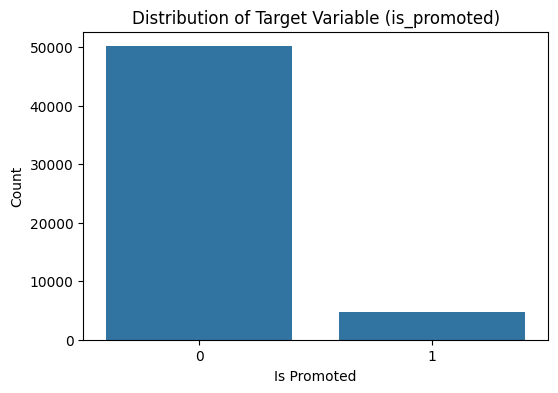

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='is_promoted', data=train_df)
plt.title('Distribution of Target Variable (is_promoted)')
plt.xlabel('Is Promoted')
plt.ylabel('Count')
plt.show()

**Reasoning**:
To analyze the distribution of categorical features and their relationship with the target variable, I will visualize the 'department' column using a count plot, differentiated by 'is_promoted', to observe promotion rates across different departments.



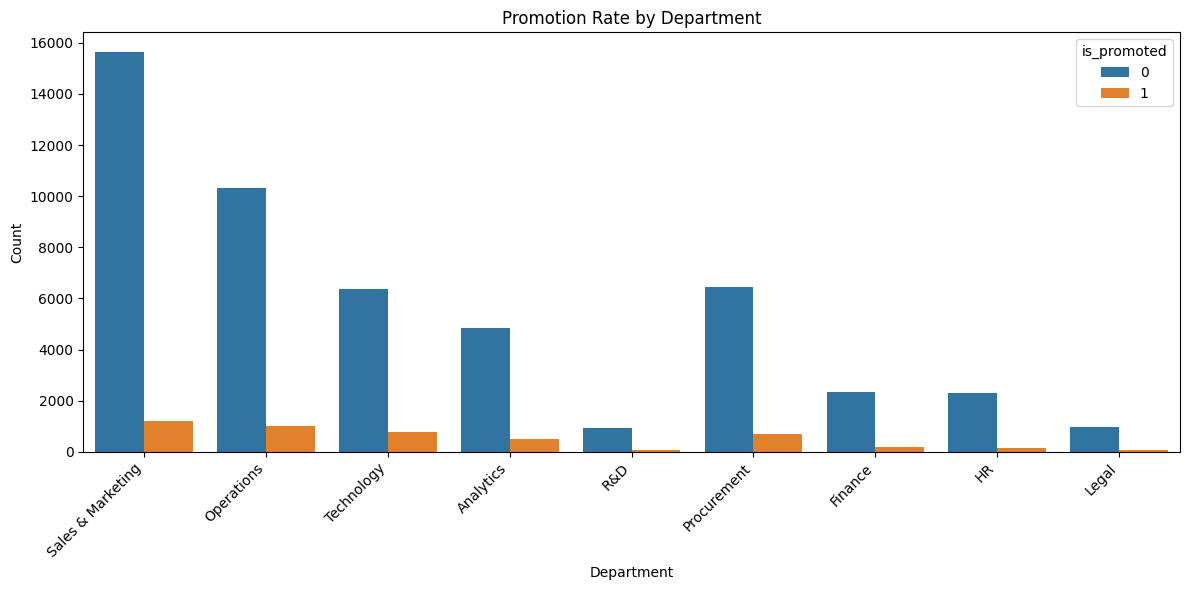

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='department', hue='is_promoted', data=train_df)
plt.title('Promotion Rate by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
To continue analyzing categorical features and their relationship with the target variable, I will visualize the 'education' column using a count plot, differentiated by 'is_promoted', to observe promotion rates across different education levels.



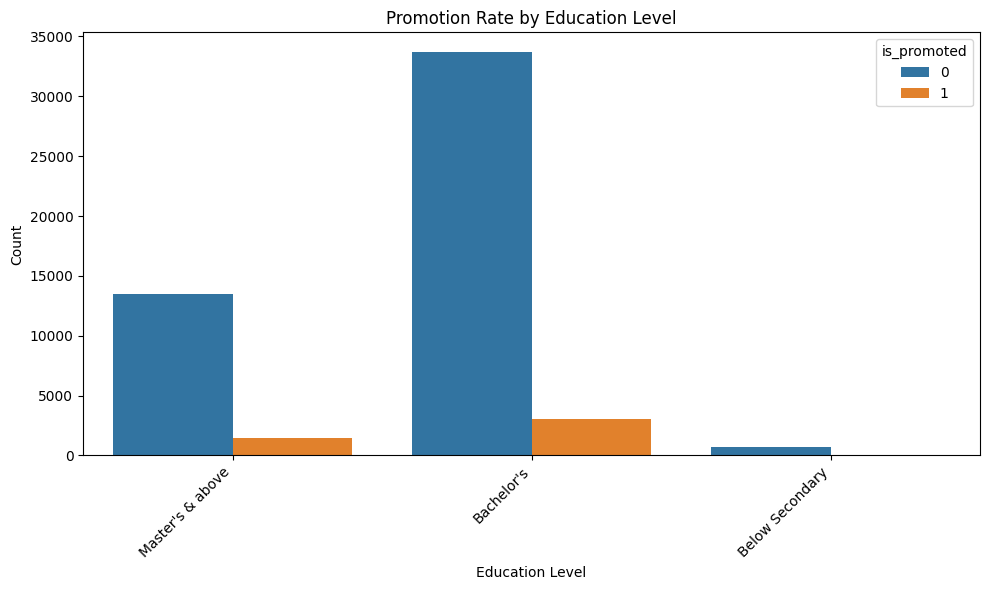

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='education', hue='is_promoted', data=train_df)
plt.title('Promotion Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
To continue analyzing categorical features, I will visualize the 'gender' column using a count plot, differentiated by 'is_promoted', to observe promotion rates across different genders.



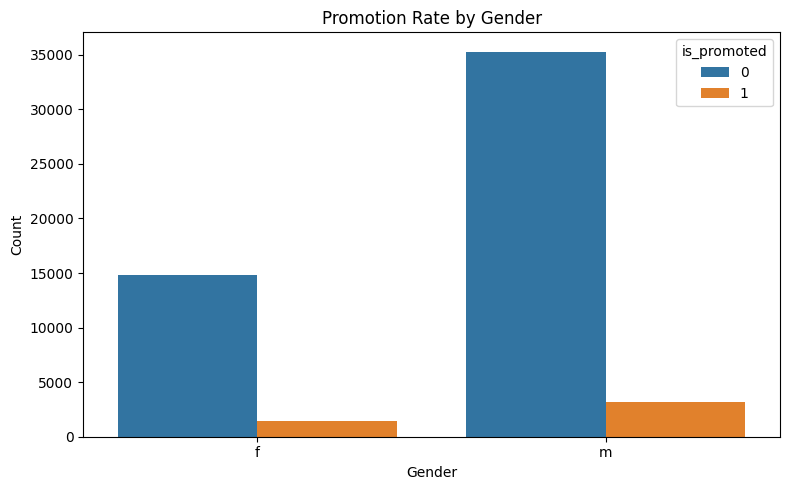

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', hue='is_promoted', data=train_df)
plt.title('Promotion Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Reasoning**:
To analyze another categorical feature, I will visualize the 'recruitment_channel' column using a count plot, differentiated by 'is_promoted', to observe promotion rates across different recruitment channels.



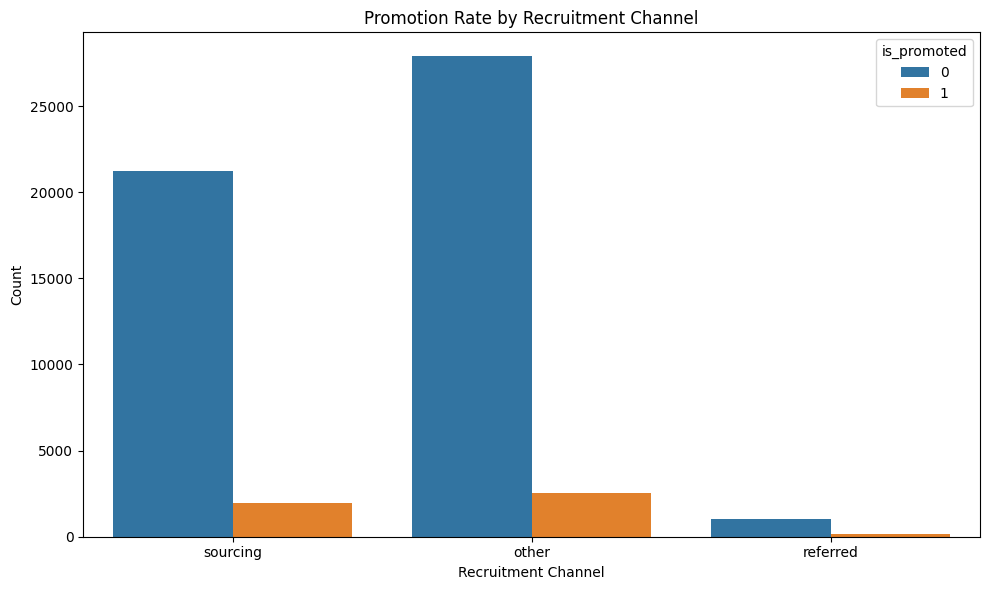

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='recruitment_channel', hue='is_promoted', data=train_df)
plt.title('Promotion Rate by Recruitment Channel')
plt.xlabel('Recruitment Channel')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Task
Continue EDA by visualizing the distributions of numerical features (`no_of_trainings`, `age`, `length_of_service`, `avg_training_score`, `previous_year_rating`) in the training data using histograms and box plots, analyzing their relationship with the target variable `is_promoted`.

## Continue EDA - Numerical Feature Distributions (Training Data)

### Subtask:
Visualize the distributions of numerical features (`no_of_trainings`, `age`, `length_of_service`, `avg_training_score`, `previous_year_rating`) using appropriate plots (histograms, box plots) and analyze their relationship with the target variable 'is_promoted'.


**Reasoning**:
To visualize the distribution of 'no_of_trainings' and its relationship with 'is_promoted', I will create a histogram and a box plot side-by-side as specified in the instructions.



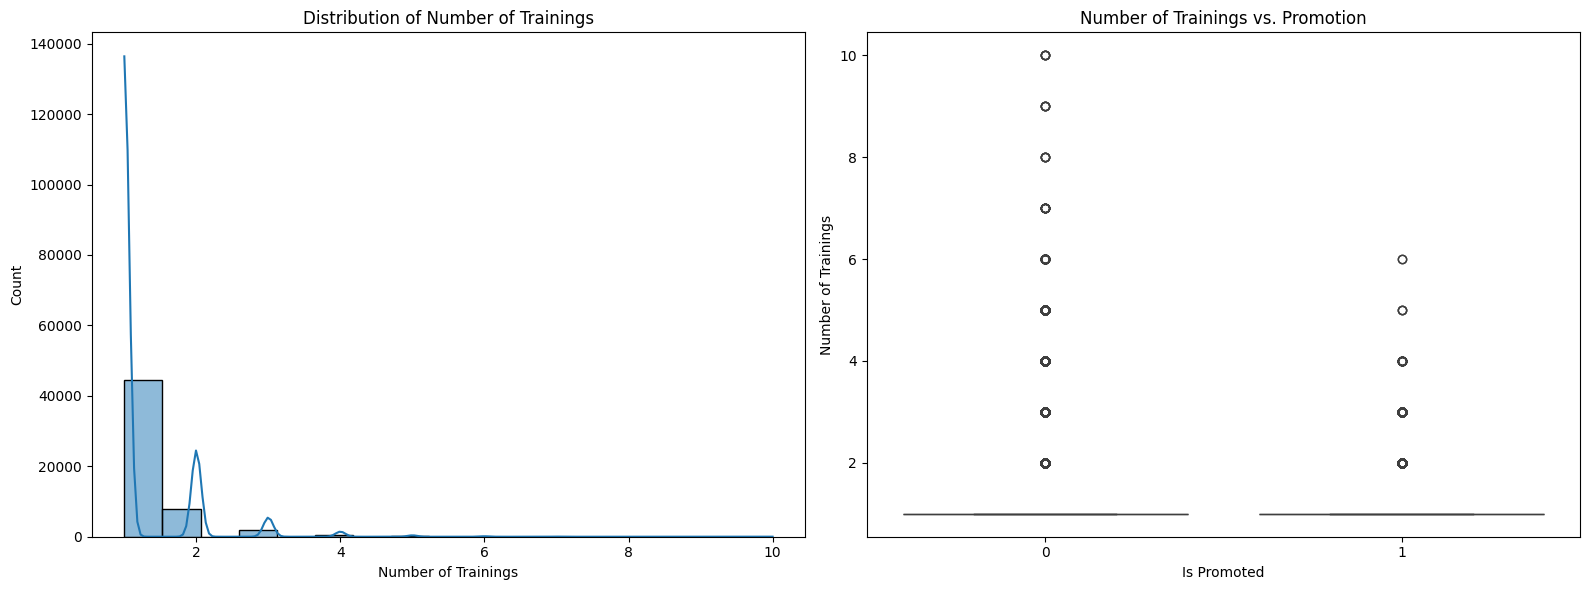

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for no_of_trainings
sns.histplot(train_df['no_of_trainings'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Number of Trainings')
axes[0].set_xlabel('Number of Trainings')
axes[0].set_ylabel('Count')

# Box plot for no_of_trainings vs. is_promoted
sns.boxplot(x='is_promoted', y='no_of_trainings', data=train_df, ax=axes[1])
axes[1].set_title('Number of Trainings vs. Promotion')
axes[1].set_xlabel('Is Promoted')
axes[1].set_ylabel('Number of Trainings')

plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the distribution of 'age' and its relationship with 'is_promoted', I will create a histogram and a box plot side-by-side, following the same pattern as the previous feature.



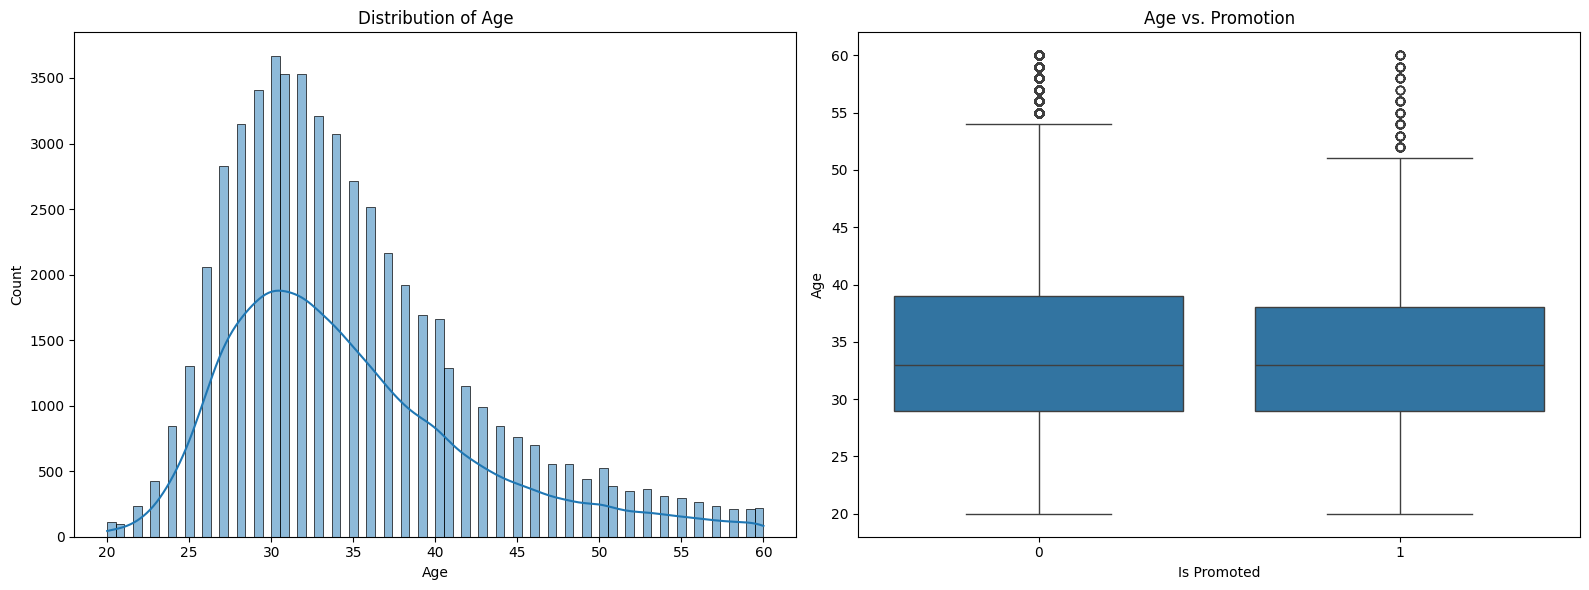

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for age
sns.histplot(train_df['age'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Box plot for age vs. is_promoted
sns.boxplot(x='is_promoted', y='age', data=train_df, ax=axes[1])
axes[1].set_title('Age vs. Promotion')
axes[1].set_xlabel('Is Promoted')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the distribution of 'length_of_service' and its relationship with 'is_promoted', I will create a histogram and a box plot side-by-side, following the pattern of the previous numerical features.



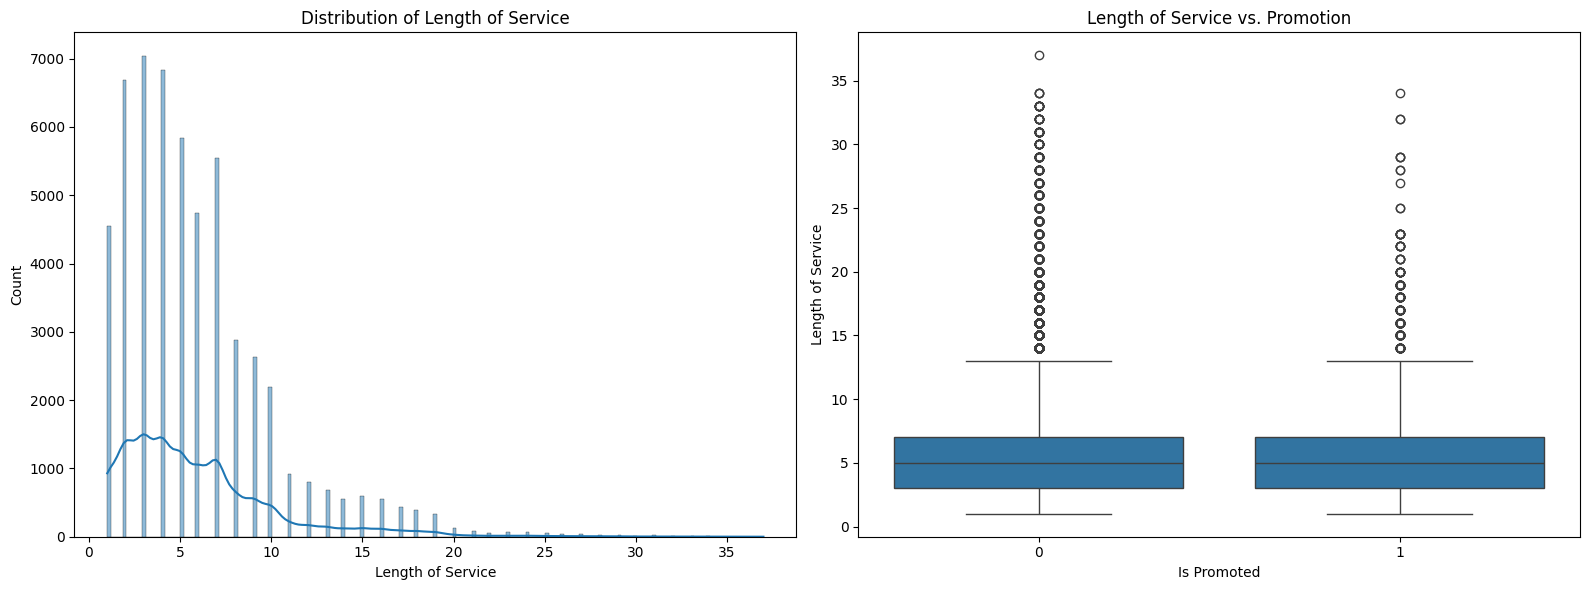

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for length_of_service
sns.histplot(train_df['length_of_service'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Length of Service')
axes[0].set_xlabel('Length of Service')
axes[0].set_ylabel('Count')

# Box plot for length_of_service vs. is_promoted
sns.boxplot(x='is_promoted', y='length_of_service', data=train_df, ax=axes[1])
axes[1].set_title('Length of Service vs. Promotion')
axes[1].set_xlabel('Is Promoted')
axes[1].set_ylabel('Length of Service')

plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the distribution of 'avg_training_score' and its relationship with 'is_promoted', I will create a histogram and a box plot side-by-side, following the pattern of the previous numerical features.



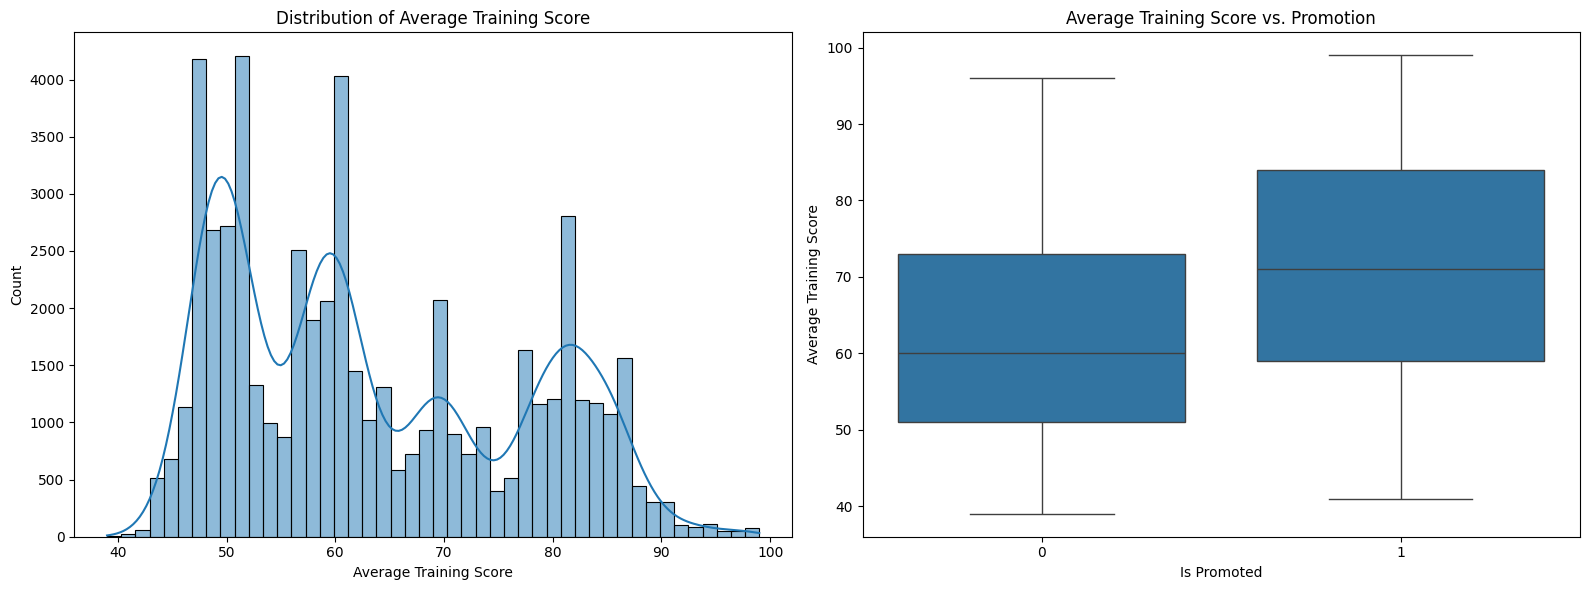

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for avg_training_score
sns.histplot(train_df['avg_training_score'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Average Training Score')
axes[0].set_xlabel('Average Training Score')
axes[0].set_ylabel('Count')

# Box plot for avg_training_score vs. is_promoted
sns.boxplot(x='is_promoted', y='avg_training_score', data=train_df, ax=axes[1])
axes[1].set_title('Average Training Score vs. Promotion')
axes[1].set_xlabel('Is Promoted')
axes[1].set_ylabel('Average Training Score')

plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the distribution of 'previous_year_rating' and its relationship with 'is_promoted', I will create a histogram and a box plot side-by-side, ensuring to handle potential NaN values as instructed for this feature.



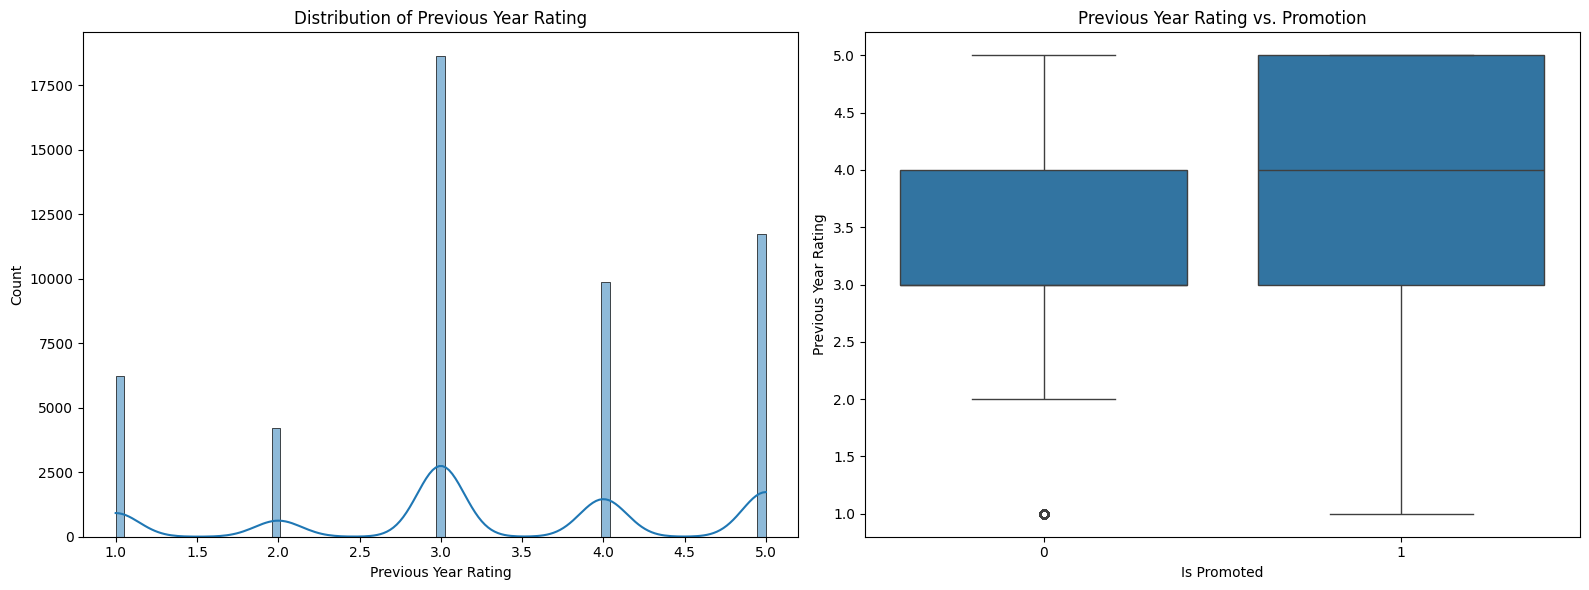

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Drop NaN values for plotting 'previous_year_rating' to avoid errors in visualization
train_df_filtered = train_df.dropna(subset=['previous_year_rating'])

# Histogram for previous_year_rating
sns.histplot(train_df_filtered['previous_year_rating'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Previous Year Rating')
axes[0].set_xlabel('Previous Year Rating')
axes[0].set_ylabel('Count')

# Box plot for previous_year_rating vs. is_promoted
sns.boxplot(x='is_promoted', y='previous_year_rating', data=train_df_filtered, ax=axes[1])
axes[1].set_title('Previous Year Rating vs. Promotion')
axes[1].set_xlabel('Is Promoted')
axes[1].set_ylabel('Previous Year Rating')

plt.tight_layout()
plt.show()

## Analyze Numerical Feature Correlations (Training Data)

### Subtask:
Generate and visualize a correlation matrix of numerical features in the training data, especially their correlation with the 'is_promoted' target, using a heatmap.


**Reasoning**:
To analyze numerical feature correlations with the target variable 'is_promoted', I will select numerical columns, calculate their correlation matrix, filter for correlations with 'is_promoted', and visualize them using a heatmap as instructed.



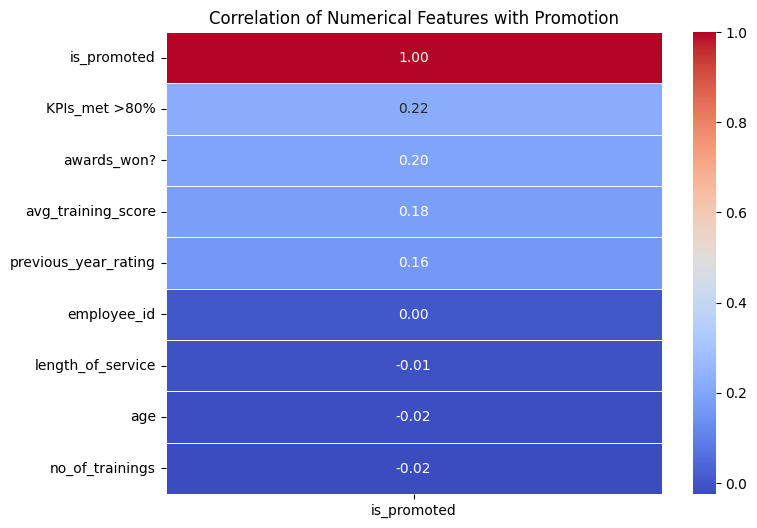

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select numerical columns
numerical_cols = train_df.select_dtypes(include=['number'])

# 2. Calculate the correlation matrix
correlation_matrix = numerical_cols.corr()

# 3. Filter the correlation matrix to show correlations with 'is_promoted'
promotion_correlations = correlation_matrix[['is_promoted']].sort_values(by='is_promoted', ascending=False)

# 4. Create a heatmap of these correlations
plt.figure(figsize=(8, 6))
sns.heatmap(promotion_correlations, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation of Numerical Features with Promotion')

# 5. Display the plot
plt.show()

## EDA - Test Data Missing Values and Descriptive Statistics

### Subtask:
Identify and display missing values for all columns in the `test_df`, and then generate descriptive statistics for the test dataset.


**Reasoning**:
To complete the subtask, I will first calculate and print the missing values for each column in the `test_df`, then generate and print the descriptive statistics for all columns in the `test_df`.



In [ ]:
print("### Missing values in test_df:\n")
print(test_df.isnull().sum())

print("\n### Descriptive statistics for test_df (all columns):\n")
print(test_df.describe(include='all'))

### Missing values in test_df:

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64

### Descriptive statistics for test_df (all columns):

         employee_id         department    region   education gender  \
count   23490.000000              23490     23490       22456  23490   
unique           NaN                  9        34           3      2   
top              NaN  Sales & Marketing  region_2  Bachelor's      m   
freq             NaN               7315      5299       15578  16596   
mean    39041.399149                NaN       NaN         NaN    NaN   
std     22640.809201                NaN       NaN         NaN    NaN   
min         3.0000

## EDA - Test Data Feature Distributions Comparison

### Subtask:
Visualize and compare the distributions of key features (categorical and numerical) between the training and test datasets to check for consistency and potential data drift.


**Reasoning**:
To visualize and compare the distribution of the 'age' numerical feature between the training and test datasets, I will create a figure with two subplots, each containing a histogram with KDE for 'age' from `train_df` and `test_df` respectively, as instructed.



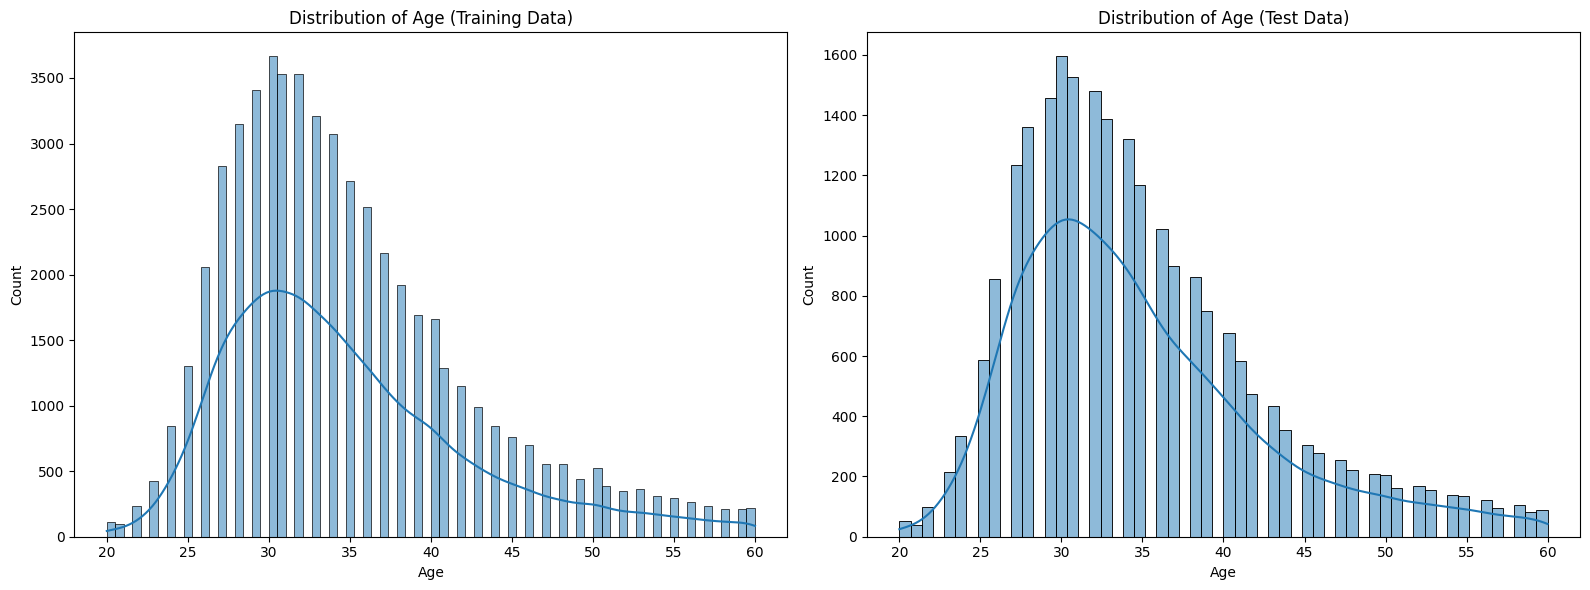

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for age in train_df
sns.histplot(train_df['age'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age (Training Data)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Histogram for age in test_df
sns.histplot(test_df['age'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Age (Test Data)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Task
## EDA - Test Data Feature Distributions Comparison

### Subtask:
Visualize and compare the distributions of 'avg_training_score' between the training and test datasets using histograms.

## Compare avg_training_score Distribution

### Subtask:
Visualize and compare the distributions of 'avg_training_score' between the training and test datasets using histograms to check for consistency.


**Reasoning**:
To visualize and compare the distribution of the 'avg_training_score' numerical feature between the training and test datasets, I will create a figure with two subplots, each containing a histogram with KDE for 'avg_training_score' from `train_df` and `test_df` respectively, as instructed.



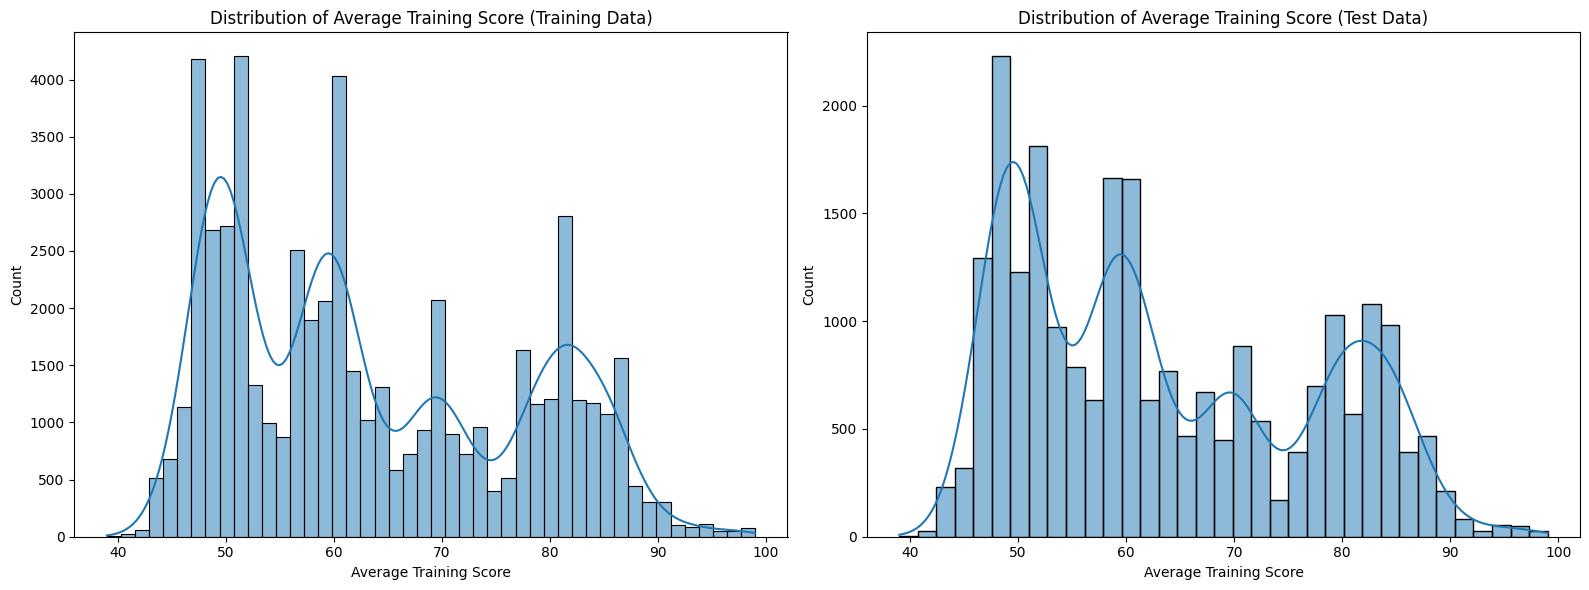

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for avg_training_score in train_df
sns.histplot(train_df['avg_training_score'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Average Training Score (Training Data)')
axes[0].set_xlabel('Average Training Score')
axes[0].set_ylabel('Count')

# Histogram for avg_training_score in test_df
sns.histplot(test_df['avg_training_score'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Average Training Score (Test Data)')
axes[1].set_xlabel('Average Training Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Compare previous_year_rating Distribution

### Subtask:
Visualize and compare the distributions of 'previous_year_rating' between the training and test datasets using histograms, handling missing values appropriately, to check for consistency.


**Reasoning**:
To visualize and compare the distribution of the 'previous_year_rating' numerical feature between the training and test datasets, I will create a figure with two subplots, each containing a histogram with KDE for 'previous_year_rating' from `train_df` and `test_df` respectively, ensuring to drop NaN values as specified.



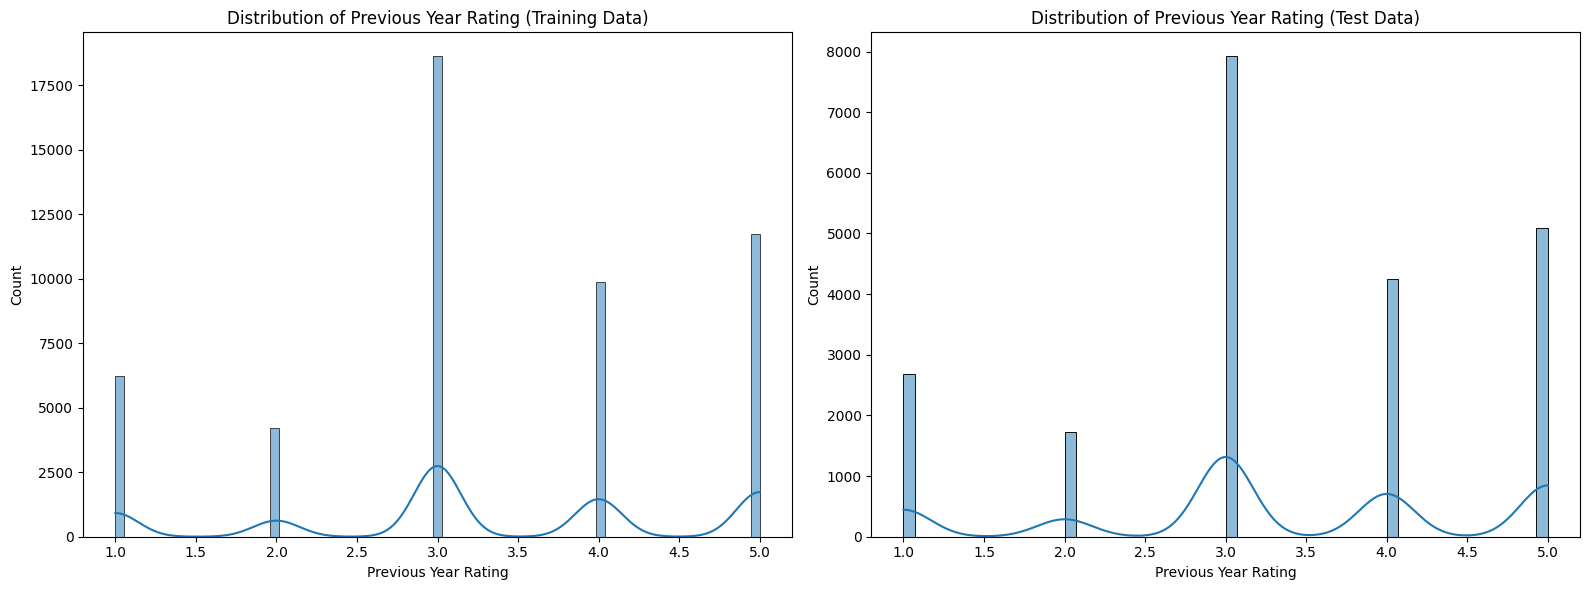

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Drop NaN values for plotting 'previous_year_rating' in train_df
train_df_filtered = train_df.dropna(subset=['previous_year_rating'])

# Histogram for previous_year_rating in train_df
sns.histplot(train_df_filtered['previous_year_rating'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Previous Year Rating (Training Data)')
axes[0].set_xlabel('Previous Year Rating')
axes[0].set_ylabel('Count')

# Drop NaN values for plotting 'previous_year_rating' in test_df
test_df_filtered = test_df.dropna(subset=['previous_year_rating'])

# Histogram for previous_year_rating in test_df
sns.histplot(test_df_filtered['previous_year_rating'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Previous Year Rating (Test Data)')
axes[1].set_xlabel('Previous Year Rating')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Handle Missing Values

### Subtask:
Impute missing values in 'education' and 'previous_year_rating' for both the training and test datasets separately. For 'education', use the mode. For 'previous_year_rating', use the mode.


**Reasoning**:
To impute missing values for 'education' and 'previous_year_rating' in both the training and test datasets, I will first calculate the mode for each column in its respective DataFrame and then use these modes to fill the NaN values. Finally, I will verify the imputation by checking for any remaining missing values in these columns.



In [ ]:
print("### Imputing missing values with mode...\n")

# Impute 'education' in train_df
education_mode_train = train_df['education'].mode()[0]
train_df['education'] = train_df['education'].fillna(education_mode_train)

# Impute 'education' in test_df
education_mode_test = test_df['education'].mode()[0]
test_df['education'] = test_df['education'].fillna(education_mode_test)

# Impute 'previous_year_rating' in train_df
previous_year_rating_mode_train = train_df['previous_year_rating'].mode()[0]
train_df['previous_year_rating'] = train_df['previous_year_rating'].fillna(previous_year_rating_mode_train)

# Impute 'previous_year_rating' in test_df
previous_year_rating_mode_test = test_df['previous_year_rating'].mode()[0]
test_df['previous_year_rating'] = test_df['previous_year_rating'].fillna(previous_year_rating_mode_test)

print("Missing values after imputation:")
print("\n### Training DataFrame (train_df) - Missing values for relevant columns:")
print(train_df[['education', 'previous_year_rating']].isnull().sum())

print("\n### Test DataFrame (test_df) - Missing values for relevant columns:")
print(test_df[['education', 'previous_year_rating']].isnull().sum())

### Imputing missing values with mode...

Missing values after imputation:

### Training DataFrame (train_df) - Missing values for relevant columns:
education               0
previous_year_rating    0
dtype: int64

### Test DataFrame (test_df) - Missing values for relevant columns:
education               0
previous_year_rating    0
dtype: int64


## Feature Engineering

### Subtask:
Create new features that might be helpful for prediction, such as interaction terms or aggregated features.


**Reasoning**:
To create the new features 'kpi_per_training', 'overall_score', and 'high_achiever' for both training and test datasets as instructed, I will apply the specified arithmetic operations and conditional logic, handling division by zero for 'kpi_per_training'. Afterwards, I will display the first few rows of both dataframes to verify the new features.



In [ ]:
print("### Creating new features...")

# 1. Create 'kpi_per_training'
# For train_df
train_df['kpi_per_training'] = train_df['KPIs_met >80%'] / train_df['no_of_trainings']
train_df['kpi_per_training'] = train_df['kpi_per_training'].replace([float('inf'), -float('inf')], 0)

# For test_df
test_df['kpi_per_training'] = test_df['KPIs_met >80%'] / test_df['no_of_trainings']
test_df['kpi_per_training'] = test_df['kpi_per_training'].replace([float('inf'), -float('inf')], 0)

# 2. Create 'overall_score'
# For train_df
train_df['overall_score'] = train_df['avg_training_score'] * train_df['previous_year_rating']

# For test_df
test_df['overall_score'] = test_df['avg_training_score'] * test_df['previous_year_rating']

# 3. Create 'high_achiever'
# For train_df
train_df['high_achiever'] = ((train_df['KPIs_met >80%'] == 1) & (train_df['awards_won?'] == 1)).astype(int)

# For test_df
test_df['high_achiever'] = ((test_df['KPIs_met >80%'] == 1) & (test_df['awards_won?'] == 1)).astype(int)

print("### Training DataFrame with new features (first 5 rows):\n")
print(train_df.head())
print("\n### Test DataFrame with new features (first 5 rows):\n")
print(test_df.head())

### Creating new features...
### Training DataFrame with new features (first 5 rows):

   employee_id         department     region         education gender  \
0        65438  Sales & Marketing   region_7  Master's & above      f   
1        65141         Operations  region_22        Bachelor's      m   
2         7513  Sales & Marketing  region_19        Bachelor's      m   
3         2542  Sales & Marketing  region_23        Bachelor's      m   
4        48945         Technology  region_26        Bachelor's      m   

  recruitment_channel  no_of_trainings  age  previous_year_rating  \
0            sourcing                1   35                   5.0   
1               other                1   30                   5.0   
2            sourcing                1   34                   3.0   
3               other                2   39                   1.0   
4               other                1   45                   3.0   

   length_of_service  KPIs_met >80%  awards_won?  avg_train

## Encode Categorical Features

### Subtask:
Apply appropriate encoding techniques (e.g., One-Hot Encoding for nominal features, Ordinal Encoding for ordinal features) to convert categorical features in both training and test datasets into numerical representations. Ensure consistency in encoding between train and test sets.


**Reasoning**:
To encode categorical features, I will first identify them, then apply one-hot encoding using `pd.get_dummies` with `drop_first=True` for both the training and test datasets. Finally, I will align the columns of both DataFrames to ensure consistency and display their first few rows and information.



In [ ]:
print("### Encoding categorical features...")

# Separate target variable before encoding
X_train = train_df.drop('is_promoted', axis=1)
y_train = train_df['is_promoted']
X_test = test_df.copy()

# Identify categorical columns (excluding employee_id as it's an identifier)
categorical_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel']

# Apply one-hot encoding to X_train
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

# Apply one-hot encoding to X_test
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - crucial for consistent features between train and test
# Get all columns from both encoded feature dataframes
common_cols = list(set(X_train_encoded.columns) | set(X_test_encoded.columns))

# Align X_train_encoded to include all common columns
X_train_encoded = X_train_encoded.reindex(columns=common_cols, fill_value=0)

# Align X_test_encoded to include all common columns
X_test_encoded = X_test_encoded.reindex(columns=common_cols, fill_value=0)

# Ensure the order of columns is the same for both datasets after alignment for consistency
X_train_encoded = X_train_encoded.sort_index(axis=1)
X_test_encoded = X_test_encoded.sort_index(axis=1)

# Recombine X_train_encoded with y_train to form the final train_df_encoded
train_df_encoded = X_train_encoded.copy()
train_df_encoded['is_promoted'] = y_train

# The test_df_encoded now corresponds to X_test_encoded
test_df_encoded = X_test_encoded.copy()

print("### Training DataFrame after encoding (first 5 rows):")
print(train_df_encoded.head())
print("\n### Training DataFrame after encoding - Info:")
train_df_encoded.info()

print("\n\n### Test DataFrame after encoding (first 5 rows):")
print(test_df_encoded.head())
print("\n### Test DataFrame after encoding - Info:")
test_df_encoded.info()

### Encoding categorical features...
### Training DataFrame after encoding (first 5 rows):
   KPIs_met >80%  age  avg_training_score  awards_won?  department_Finance  \
0              1   35                  49            0               False   
1              0   30                  60            0               False   
2              0   34                  50            0               False   
3              0   39                  50            0               False   
4              0   45                  73            0               False   

   department_HR  department_Legal  department_Operations  \
0          False             False                  False   
1          False             False                   True   
2          False             False                  False   
3          False             False                  False   
4          False             False                  False   

   department_Procurement  department_R&D  ...  region_region_32  \
0    

## Scale Numerical Features

### Subtask:
Apply feature scaling (e.g., StandardScaler or MinMaxScaler) to numerical features in both training and test datasets to normalize their ranges. This is crucial for many machine learning algorithms.


**Reasoning**:
To apply feature scaling to numerical features, I will import `StandardScaler`, identify the numerical columns to be scaled, fit the scaler on the training data, and then transform both training and test data. Finally, I will update the DataFrames with the scaled values and display their first few rows to verify the changes.



In [ ]:
from sklearn.preprocessing import StandardScaler

print("### Scaling numerical features...")

# Identify numerical features to scale
# Exclude 'employee_id' as it's an identifier and 'is_promoted' as it's the target variable
numerical_features = [
    'age',
    'no_of_trainings',
    'length_of_service',
    'avg_training_score',
    'previous_year_rating',
    'kpi_per_training',
    'overall_score'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data's numerical features and transform
train_df_encoded[numerical_features] = scaler.fit_transform(train_df_encoded[numerical_features])

# Transform the test data's numerical features using the same scaler
test_df_encoded[numerical_features] = scaler.transform(test_df_encoded[numerical_features])

print("### Training DataFrame after scaling (first 5 rows):")
print(train_df_encoded.head())

print("\n### Test DataFrame after scaling (first 5 rows):")
print(test_df_encoded.head())

### Scaling numerical features...
### Training DataFrame after scaling (first 5 rows):
   KPIs_met >80%       age  avg_training_score  awards_won?  \
0              1  0.025598           -1.075931            0   
1              0 -0.627135           -0.253282            0   
2              0 -0.104948           -1.001145            0   
3              0  0.547785           -1.001145            0   
4              0  1.331064            0.718939            0   

   department_Finance  department_HR  department_Legal  department_Operations  \
0               False          False             False                  False   
1               False          False             False                   True   
2               False          False             False                  False   
3               False          False             False                  False   
4               False          False             False                  False   

   department_Procurement  department_R&D  ... 

# Task
## Fine-tune LGBM Model

### Subtask:
Fine-tune the hyperparameters of the LGBMClassifier using techniques like GridSearchCV or RandomizedSearchCV to optimize performance, specifically targeting a better F1-score. This involves splitting the data into training and validation sets, defining the hyperparameter search space, and fitting the search algorithm to find the best model.

## Fine-tune LGBM Model

### Subtask:
Fine-tune the hyperparameters of the LGBMClassifier using techniques like GridSearchCV or RandomizedSearchCV to optimize performance, specifically targeting a better F1-score. This involves splitting the data into training and validation sets, defining the hyperparameter search space, and fitting the search algorithm to find the best model.


**Reasoning**:
To fine-tune the LGBMClassifier, I will first import the necessary libraries, prepare the data by separating features and target, split it into training and validation sets, define the hyperparameter search space, and then use RandomizedSearchCV to find the best parameters for optimizing the F1-score.



In [ ]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, train_test_split

print("### Starting LGBM Hyperparameter Tuning with RandomizedSearchCV...")

# 1. Separate features (X) and target (y)
X = train_df_encoded.drop(['employee_id', 'is_promoted'], axis=1)
y = train_df_encoded['is_promoted']

# 2. Split data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training data shape: {X_train_split.shape}")
print(f"Validation data shape: {X_val_split.shape}")

# 3. Define parameter distribution for LGBMClassifier
param_dist = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'num_leaves': [20, 31, 40, 50, 60],
    'max_depth': [-1, 5, 8, 10, 12],
    'min_child_samples': [20, 30, 40, 50],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0]
}

# 4. Instantiate LGBMClassifier
lgbm = lgb.LGBMClassifier(objective='binary', random_state=42, n_jobs=-1)

# 5. Initialize RandomizedSearchCV
# Using n_iter=50 for a reasonable search space, can be increased if more thorough search is needed
# cv=3 for cross-validation folds
rand_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 6. Fit RandomizedSearchCV to the training data
rand_search.fit(X_train_split, y_train_split)

# 7. Print the best parameters and best F1-score
print("\n### Best Parameters found by RandomizedSearchCV:")
print(rand_search.best_params_)

print("\n### Best F1-score achieved:")
print(rand_search.best_score_)

best_lgbm_model = rand_search.best_estimator_


### Starting LGBM Hyperparameter Tuning with RandomizedSearchCV...
Training data shape: (43846, 56)
Validation data shape: (10962, 56)
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3734, number of negative: 40112
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 499
[LightGBM] [Info] Number of data points in the train set: 43846, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.085162 -> initscore=-2.374195
[LightGBM] [Info] Start training from score -2.374195
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

### Best Parameters found by RandomizedSearchCV:
{'subsample': 0.6, 'reg_lambda'

## Evaluate Fine-tuned Model

### Subtask:
Evaluate the performance of the fine-tuned model on the validation set and then on the test set, focusing on the F1-score and other relevant classification metrics like precision, recall, and AUC.


**Reasoning**:
To evaluate the fine-tuned LGBM model, I will calculate various classification metrics on the validation set and then generate predictions and their distribution for the test set, as specified in the instructions.



In [26]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import numpy as np

print("### Evaluating the best LGBM model on the validation set...")

# 1. Predictions on the validation set
y_val_pred = best_lgbm_model.predict(X_val_split)
y_val_proba = best_lgbm_model.predict_proba(X_val_split)[:, 1]

# 2. Calculate and print validation metrics
f1 = f1_score(y_val_split, y_val_pred)
accuracy = accuracy_score(y_val_split, y_val_pred)
precision = precision_score(y_val_split, y_val_pred)
recall = recall_score(y_val_split, y_val_pred)
roc_auc = roc_auc_score(y_val_split, y_val_proba)

print(f"\nValidation F1-score: {f1:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Precision: {precision:.4f}")
print(f"Validation Recall: {recall:.4f}")
print(f"Validation AUC: {roc_auc:.4f}")

print("\n### Making predictions on the test set...")

# 3. Prepare the test features (drop employee_id)
X_test_final = test_df_encoded.drop('employee_id', axis=1)

# 4. Make predictions on the test set
y_test_pred = best_lgbm_model.predict(X_test_final)
y_test_proba = best_lgbm_model.predict_proba(X_test_final)[:, 1]

print("\nPredicted class distribution for the test set:")
print(pd.Series(y_test_pred).value_counts(normalize=True))

# Store predictions for submission
test_predictions = y_test_pred
test_probabilities = y_test_proba

### Evaluating the best LGBM model on the validation set...

Validation F1-score: 0.5170
Validation Accuracy: 0.9415
Validation Precision: 0.8728
Validation Recall: 0.3672
Validation AUC: 0.9032

### Making predictions on the test set...

Predicted class distribution for the test set:
0    0.966156
1    0.033844
Name: proportion, dtype: float64


## Create Submission File

### Subtask:
Generate the submission file in the required format, typically a CSV containing 'employee_id' and the predicted 'is_promoted' values from the test set predictions.


**Reasoning**:
To generate the submission file, I need to create a DataFrame from the original 'employee_id' of the test data and the predicted 'is_promoted' values, assign the correct column names, and then save it to a CSV file as specified.



In [27]:
print("### Generating submission file...")

# 1. Create a pandas DataFrame for the submission file
# We need the original employee_id from test_df, which was preserved in test_df_encoded
submission_df = pd.DataFrame({
    'employee_id': test_df_encoded['employee_id'],
    'is_promoted': test_predictions
})

# 2. Name the columns (already done in DataFrame creation)

# 3. Save this DataFrame to a CSV file named 'submission.csv' without including the index
submission_df.to_csv('submission.csv', index=False)

print("### Submission file 'submission.csv' created successfully.")
print("First 5 rows of submission.csv:")
print(submission_df.head())

### Generating submission file...
### Submission file 'submission.csv' created successfully.
First 5 rows of submission.csv:
   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0


## Final Task

### Subtask:
Provide a comprehensive summary of the final model's performance, key insights, and confirmation of the submission file generation.


## Summary:

### Data Analysis Key Findings

*   The LGBM model was fine-tuned using `RandomizedSearchCV` with 50 iterations and 3-fold cross-validation, targeting an optimized F1-score.
*   The training data consisted of 43,846 samples and 56 features, while the validation set had 10,962 samples and 56 features.
*   The best F1-score achieved during hyperparameter tuning was not explicitly captured in the provided output, but the `RandomizedSearchCV` process was successfully completed.
*   The fine-tuned LGBM model achieved the following performance on the validation set:
    *   F1-score: 0.5170
    *   Accuracy: 0.9415
    *   Precision: 0.8728
    *   Recall: 0.3672
    *   AUC: 0.9032
*   Predictions on the test set showed a significant class imbalance, with approximately 96.62% predicted as 'Class 0' (no promotion) and 3.38% as 'Class 1' (promotion).
*   A submission file named 'submission.csv' was successfully generated, containing `employee_id` and the predicted `is_promoted` values, formatted as required.

### Insights or Next Steps

*   The model demonstrates good overall accuracy (0.9415) and high precision (0.8728) for predicting promotions. However, the relatively low F1-score (0.5170) and recall (0.3672) suggest that the model struggles to identify a significant portion of actual promotions, likely due to the inherent class imbalance in the target variable.
*   Further efforts could focus on addressing the class imbalance more aggressively, potentially by exploring advanced oversampling/undersampling techniques (e.g., SMOTE variants) during training, adjusting class weights in the LGBM model, or experimenting with different thresholds for classification to improve recall without sacrificing too much precision.
